In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense


In [3]:
df = pd.read_csv(r"C:\Users\Ali\Downloads\Graduate_admission_dataset\Admission_Predict_Ver1.1.csv")

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           500 non-null    int64  
 8   Chance of Admit    500 non-null    float64
dtypes: float64(4), int64(5)
memory usage: 35.3 KB


In [5]:
df.shape

(500, 9)

In [6]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.drop(columns = ['Serial No.'], inplace = True)

In [16]:
X = df.iloc[:, 0:-1]
y = df.iloc[:,-1]

In [17]:
X

,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research
0,337,118,4,4.5,4.5,9.65,1
1,324,107,4,4.0,4.5,8.87,1
2,316,104,3,3.0,3.5,8.00,1
3,322,110,3,3.5,2.5,8.67,1
4,314,103,2,2.0,3.0,8.21,0
...,...,...,...,...,...,...,...
495,332,108,5,4.5,4.0,9.02,1
496,337,117,5,5.0,5.0,9.87,1
497,330,120,5,4.5,5.0,9.56,1
498,312,103,4,4.0,5.0,8.43,0


In [18]:
y

0      0.92
1      0.76
2      0.72
3      0.80
4      0.65
       ... 
495    0.87
496    0.96
497    0.93
498    0.73
499    0.84
Name: Chance of Admit , Length: 500, dtype: float64

In [19]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [22]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [23]:
X_train_scaled

array([[0.62      , 0.67857143, 0.5       , ..., 0.71428571, 0.65064103,
        1.        ],
       [0.52      , 0.67857143, 0.75      , ..., 1.        , 0.55769231,
        0.        ],
       [0.26      , 0.35714286, 0.5       , ..., 0.42857143, 0.54487179,
        0.        ],
       ...,
       [0.24      , 0.25      , 0.        , ..., 0.14285714, 0.14423077,
        0.        ],
       [0.38      , 0.46428571, 0.25      , ..., 0.71428571, 0.28205128,
        0.        ],
       [0.48      , 0.5       , 0.25      , ..., 0.57142857, 0.46474359,
        0.        ]], shape=(400, 7))

In [24]:
model = Sequential()
model.add(Dense(7, activation = 'relu',input_dim = 7))
model.add(Dense(7, activation = 'relu'))
model.add(Dense(1, activation = 'linear'))


c:\Users\Ali\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             8 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 120 (480.00 B)

 Trainable params: 120 (480.00 B)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.compile(loss = 'mean_squared_error', optimizer = 'Adam')

In [27]:
history = model.fit(X_train_scaled, y_train, epochs = 100, validation_split = 0.2)

Epoch 1/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 30s 323ms/step - loss: 0.8721 - val_loss: 0.8733
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 156ms/step - loss: 0.6947 - val_loss: 0.6886
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 153ms/step - loss: 0.5375 - val_loss: 0.5150
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 197ms/step - loss: 0.3939 - val_loss: 0.3673
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 132ms/step - loss: 0.2766 - val_loss: 0.2466
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 265ms/step - loss: 0.1828 - val_loss: 0.1554
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 233ms/step - loss: 0.1124 - val_loss: 0.0927
Epoch 8/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 159ms/step - loss: 0.0657 - val_loss: 0.0516
Epoch 9/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 133ms/step - loss: 0.0375 - val_loss: 0.0274
Epoch 10/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 139ms/step - loss: 0.0236 - val_loss: 0.0176
Epoch 11/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 111ms/step - loss: 0.0183 - val_loss: 0.0152
Epoch 12/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 

In [28]:
y_pred = model.predict(X_test_scaled)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 175ms/step


In [29]:
from sklearn.metrics import r2_score
r2_score(y_test, y_pred)

0.7882716894262478

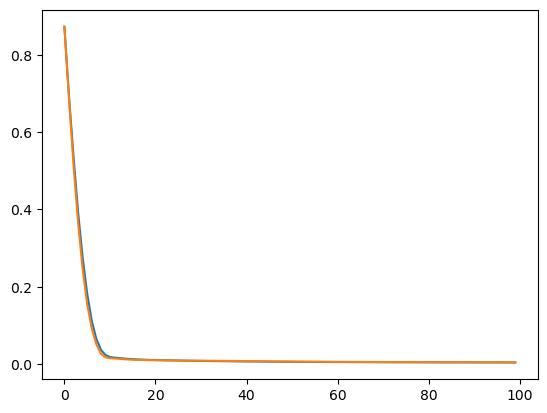

In [30]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])